## Compute and plot escape times (#returns) on a ray

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import rebound
from matplotlib.colors import SymLogNorm
import os


from src.integrator.integrate import number_returns_before_escape as returns
from src.utils.boundary import B2_v_func

In [2]:
e = 0.6
t0 = 0

B2_v = B2_v_func(e)
v_max = B2_v(t0)

In [3]:
N_v = 10
max_ret = 10
t_max = 50

v_vals = np.linspace(0, v_max, N_v, endpoint = False)
ret_vals = np.array([returns(e, v0, t0, max_ret = max_ret, t_max = t_max) for v0 in v_vals])

In [5]:
print(v_vals)

[0.         0.3073225  0.61464499 0.92196749 1.22928999 1.53661248
 1.84393498 2.15125748 2.45857997 2.76590247]


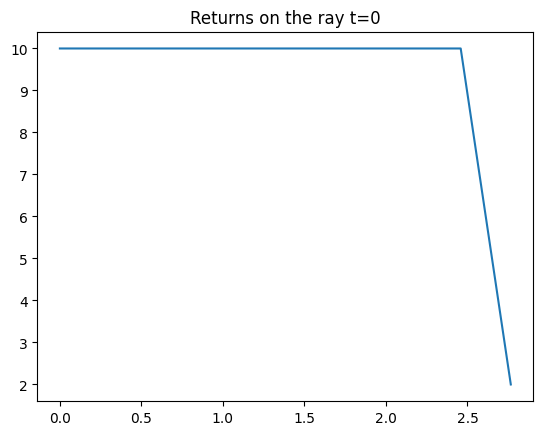

In [4]:
plt.plot(v_vals, ret_vals)
plt.title(f"Returns on the ray t={t0}")
plt.show()

Note that the island of stability seems to reach very far so we choose some value initial value of v around where the island of stability seems to end

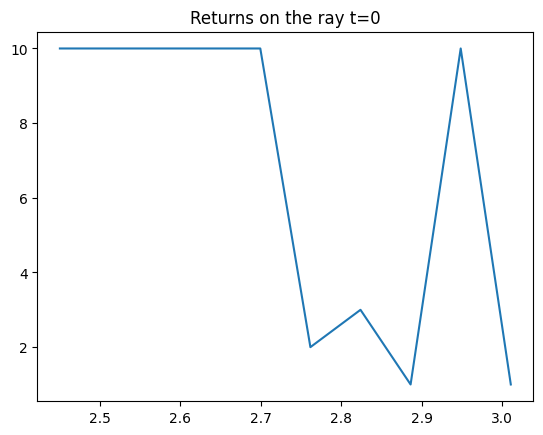

In [6]:
N_v = 10
max_ret = 10
t_max = 50
v_min = 2.45

v_vals = np.linspace(v_min, v_max, N_v, endpoint = False)
ret_vals = np.array([returns(e, v0, t0, max_ret = max_ret, t_max = t_max) for v0 in v_vals])
plt.plot(v_vals, ret_vals)
plt.title(f"Returns on the ray t={t0}")
plt.show()

We zoom in once more

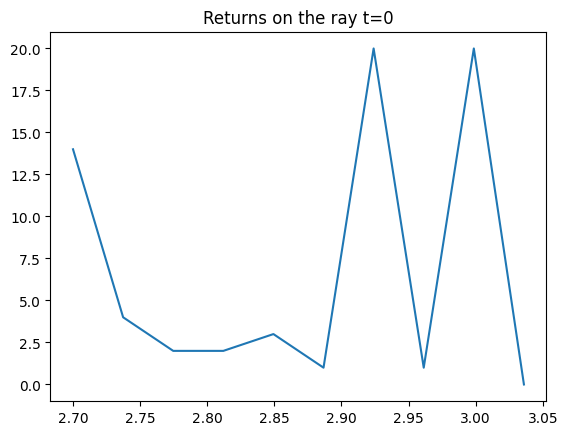

In [7]:
N_v = 10
max_ret = 20
t_max = 50
v_min = 2.7

v_vals = np.linspace(v_min, v_max, N_v, endpoint = False)
ret_vals = np.array([returns(e, v0, t0, max_ret = max_ret, t_max = t_max) for v0 in v_vals])
plt.plot(v_vals, ret_vals)
plt.title(f"Returns on the ray t={t0}")
plt.show()

We increase resolution

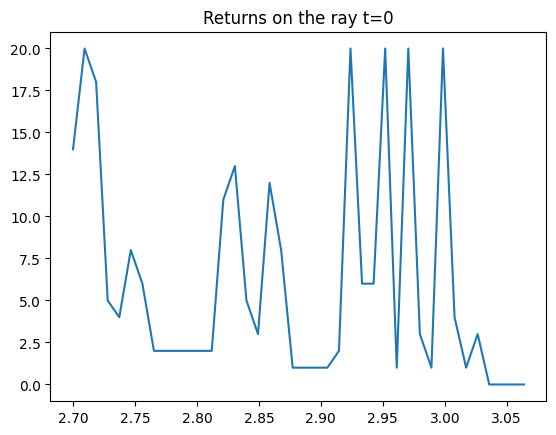

In [ ]:
N_v = 
max_ret = 20
t_max = 50
v_min = 2.7

v_vals = np.linspace(v_min, v_max, N_v, endpoint = False)
ret_vals = np.array([returns(e, v0, t0, max_ret = max_ret, t_max = t_max) for v0 in v_vals])
fig, ax = plt.subplots()
ax.plot(v_vals, ret_vals)
ax.set_yticks([0, 1, 2, 4, 8, 12, 16, 20])
plt.title(f"Returns on the ray t={t0}")
plt.show()

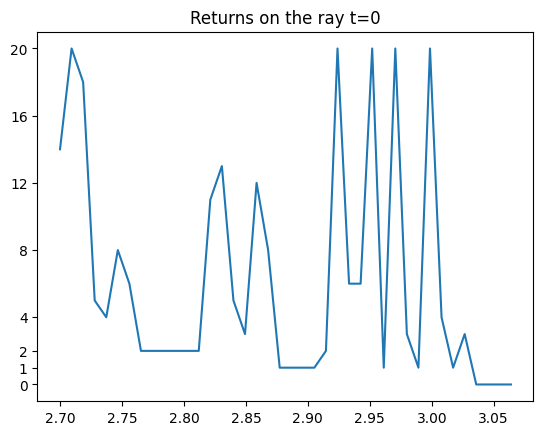

Let us study the returns plateau around 2.90

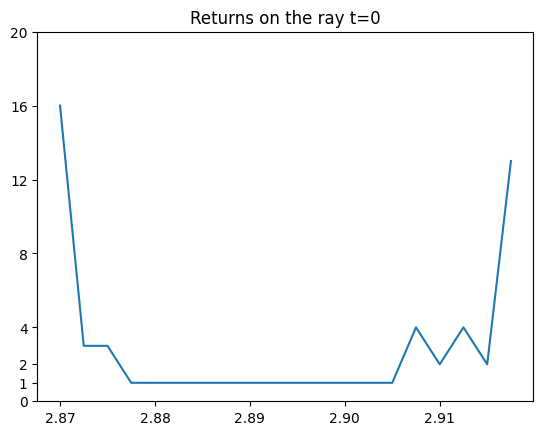

In [12]:
N_v = 20
max_ret = 20
t_max = 50
v_left = 2.87
v_right = 2.92

v_vals = np.linspace(v_left, v_right, N_v, endpoint = False)
ret_vals = np.array([returns(e, v0, t0, max_ret = max_ret, t_max = t_max) for v0 in v_vals])
fig, ax = plt.subplots()
ax.plot(v_vals, ret_vals)
ax.set_yticks([0, 1, 2, 4, 8, 12, 16, 20])
plt.title(f"Returns on the ray t={t0}")
plt.show()

It's easy to tell that there is a clear 1-escape basin in some interval of v0 values around 2.88-2.90 

Let's try to see what the returns behaviour is as we approach the boundary of the central stable island.

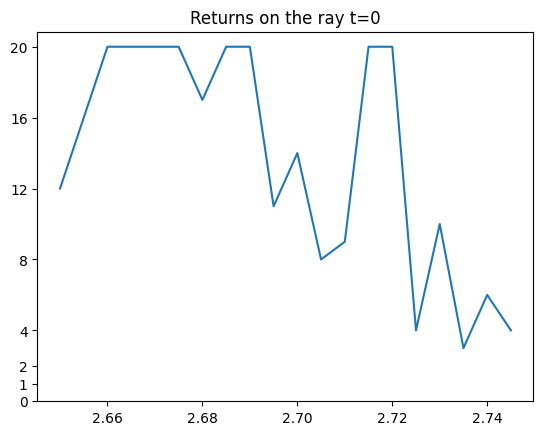

In [13]:
N_v = 20
max_ret = 20
t_max = 50
v_left = 2.65
v_right = 2.75

v_vals = np.linspace(v_left, v_right, N_v, endpoint = False)
ret_vals = np.array([returns(e, v0, t0, max_ret = max_ret, t_max = t_max) for v0 in v_vals])
fig, ax = plt.subplots()
ax.plot(v_vals, ret_vals)
ax.set_yticks([0, 1, 2, 4, 8, 12, 16, 20])
plt.title(f"Returns on the ray t={t0}")
plt.show()

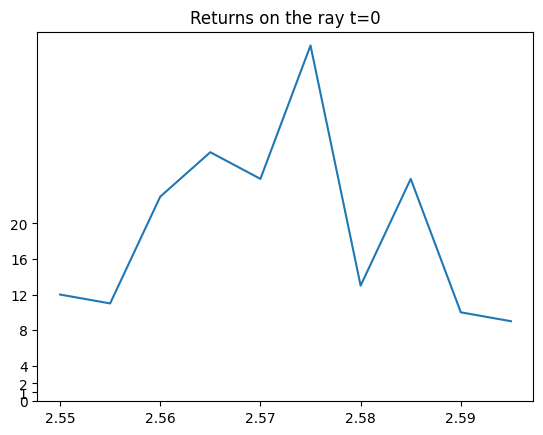

In [14]:
N_v = 10
max_ret = 40
t_max = 50
v_left = 2.55
v_right = 2.60

v_vals = np.linspace(v_left, v_right, N_v, endpoint = False)
ret_vals = np.array([returns(e, v0, t0, max_ret = max_ret, t_max = t_max) for v0 in v_vals])
fig, ax = plt.subplots()
ax.plot(v_vals, ret_vals)
ax.set_yticks([0, 1, 2, 4, 8, 12, 16, 20])
plt.title(f"Returns on the ray t={t0}")
plt.show()

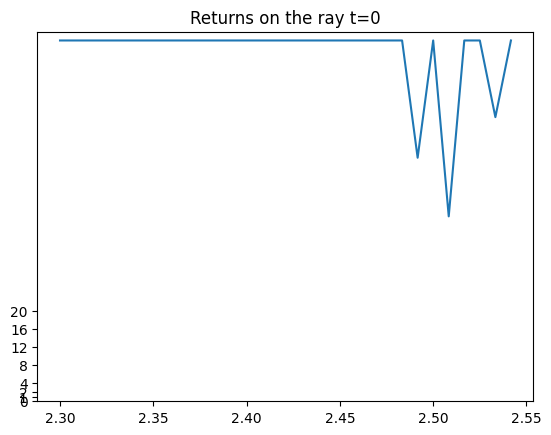

In [15]:
N_v = 30
max_ret = 80
t_max = 50
v_left = 2.30
v_right = 2.55

v_vals = np.linspace(v_left, v_right, N_v, endpoint = False)
ret_vals = np.array([returns(e, v0, t0, max_ret = max_ret, t_max = t_max) for v0 in v_vals])
fig, ax = plt.subplots()
ax.plot(v_vals, ret_vals)
ax.set_yticks([0, 1, 2, 4, 8, 12, 16, 20])
plt.title(f"Returns on the ray t={t0}")
plt.show()

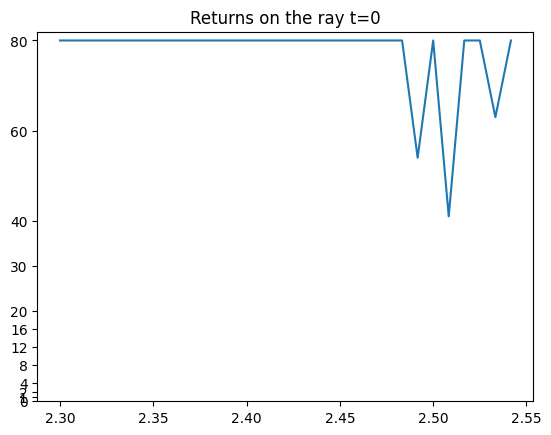

In [17]:
fig, ax = plt.subplots()
ax.plot(v_vals, ret_vals)
ax.set_yticks([0, 1, 2, 4, 8, 12, 16, 20, 30, 40, 60, 80])
plt.title(f"Returns on the ray t={t0}")
plt.show()

We also want to see what kinds of orbits these points correspond to

In [18]:
from src.integrator.integrate import phi

In [19]:
def iterates(e, v0, t0, max_iter = 20, t_max = 100):
    '''
    Returns two arrays with the v,t values 
    of the iterates by phi() of (v0, t0)
    '''
    i = 0
    v = v0
    t = t0
    iter_v = np.zeros((max_iter + 1))
    iter_t = np.zeros((max_iter + 1))
    iter_v[0] = v0
    iter_t[0] = t0

    for i in range(1, max_iter + 1):
        v, t = phi(e, v, t, t_max = t_max)
        if v is None:
            # cut off the array
            iter_v = iter_v[:i]
            iter_t = iter_t[:i]

            return iter_v, iter_t
        
        iter_v[i] = v
        iter_t[i] = t
    
    return iter_v, iter_t


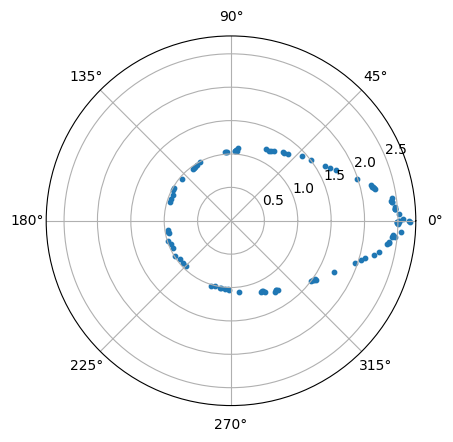

In [28]:
v0 = 2.51
t0 = 0

iter_v, iter_t = iterates(e, v0, t0, max_iter = 100)
fig, ax = plt.subplots(subplot_kw = {'projection': 'polar'})
ax.scatter(iter_t, iter_v, s = 10)

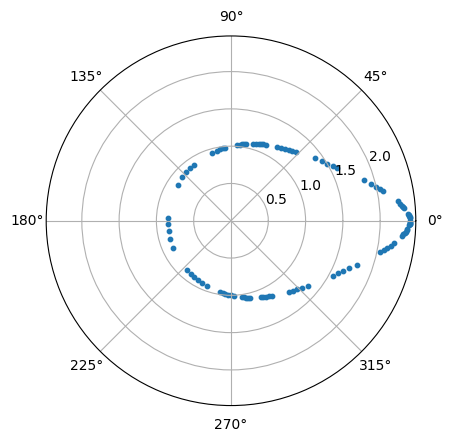

In [29]:
v0 = 2.40
t0 = 0

iter_v, iter_t = iterates(e, v0, t0, max_iter = 100)
fig, ax = plt.subplots(subplot_kw = {'projection': 'polar'})
ax.scatter(iter_t, iter_v, s = 10)